## 3_rq1a_hedonic_model_features_analysis.ipynb

This code builds and evaluates a hedonic regression model to analyze how key structural, locational, and macroeconomic features influence housing prices, and validates the results using Random Forest feature importance.

Research 1_a: What is the relationship between key property features and variations in residential house prices?

### 1. Imports Library

In [17]:
# Imports
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import Image, display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import dataframe_image as dfi

import warnings
warnings.filterwarnings("ignore", category=Warning)

### 2. Hypothesis

In [18]:
# 1) Define hypotheses & mapping
# var: the exact regressor name used in the formula
# vtype: 'log' (log-log elasticity), 'linear' (log-level semi-elasticity),
#        'binary' (0/1 → percent difference), 'fe' (fixed-effects joint test)
hypo_specs = [
    # --- Structural (H1) ---
    {"H": "H1a", "group": "Structural", "feature": "GrLivArea",
     "var": "GrLivArea", "vtype": "linear",
     "hypothesis": "Larger floor area is positively associated with house prices", "expect": "+"},
    {"H": "H1b", "group": "Structural", "feature": "BedroomAbvGr",
     "var": "BedroomAbvGr", "vtype": "linear",
     "hypothesis": "More bedrooms are positively associated with house prices", "expect": "+"},
    {"H": "H1c", "group": "Structural", "feature": "Bathrooms",
     "var": "Bathrooms", "vtype": "linear",
     "hypothesis": "More bathrooms are positively associated with house prices", "expect": "+"},
    {"H": "H1d", "group": "Structural", "feature": "PropertyAge",
     "var": "PropertyAge", "vtype": "linear",
     "hypothesis": "Older property age is negatively associated with house prices", "expect": "-"},
    {"H": "H1e", "group": "Structural", "feature": "GarageCars",
     "var": "GarageCars", "vtype": "linear",
     "hypothesis": "Larger GarageCars is positively associated with house prices", "expect": "+"},
    {"H": "H1f", "group": "Structural", "feature": "TotalBsmtSF",
     "var": "TotalBsmtSF", "vtype": "linear",
     "hypothesis": "Larger basement area is positively associated with house prices", "expect": "+"},
    {"H": "H1g", "group": "Structural", "feature": "OverallQual",
     "var": "OverallQual", "vtype": "linear",
     "hypothesis": "Higher overall quality is positively associated with house prices", "expect": "+"},
    {"H": "H1h", "group": "Structural", "feature": "LotArea",
     "var": "LotArea", "vtype": "linear",
     "hypothesis": "Larger lot area is positively associated with house prices", "expect": "+"},
    {"H": "H1i", "group": "Structural", "feature": "TotRmsAbvGrd",
     "var": "TotRmsAbvGrd", "vtype": "linear",
     "hypothesis": "More total room above grade is positively associated with house prices", "expect": "+"},
    {"H": "H1j", "group": "Structural", "feature": "2ndFlrSF",
     "var": "2ndFlrSF", "vtype": "linear",
     "hypothesis": "Larger second floor area is positively associated with  house prices", "expect": "-"},
    {"H": "H1k", "group": "Structural", "feature": "GarageArea",
     "var": "GarageArea", "vtype": "linear",
     "hypothesis": "Larger garage area is positively associated with  house prices", "expect": "+"},
    {"H": "H1l", "group": "Structural", "feature": "BsmtFinSF1",
     "var": "BsmtFinSF1", "vtype": "linear",
     "hypothesis": "Larger  finish basement area is positively associated with  house prices", "expect": "+"},
    {"H": "H1m", "group": "Structural", "feature": "BsmtUnfSF",
     "var": "BsmtUnfSF", "vtype": "linear",
     "hypothesis": "Larger unfinish basement area is positively associated with  house prices", "expect": "+"},
    {"H": "H1n", "group": "Structural", "feature": "1stFlrSF",
     "var": "1stFlrSF", "vtype": "linear",
     "hypothesis": "Larger floor area is positively associated with  house prices", "expect": "+"},
    {"H": "H1o", "group": "Structural", "feature": "GarageYrBlt",
     "var": "C(GarageYrBlt)", "vtype": "fe",
     "hypothesis": "older year garage was built is negatively associated with house prices", "expect": "-"},
    {"H": "H1p", "group": "Structural", "feature": "WoodDeckSF",
     "var": "WoodDeckSF", "vtype": "linear",
     "hypothesis": "Larger wood deck area is positively associated with house prices", "expect": "+"},

    {"H": "H1q", "group": "Structural", "feature": "OpenPorchSF",
     "var": "OpenPorchSF", "vtype": "liner",
     "hypothesis": "Larger open porch area is negatively associated with house prices", "expect": "-"},

    {"H": "H1r", "group": "Structural", "feature": "MasVnrArea",
     "var": "MasVnrArea", "vtype": "linear",
     "hypothesis": "Larger masonry veneer area is positively associated with house prices", "expect": "-"},

    {"H": "H1s", "group": "Structural", "feature": "OverallCond",
     "var": "OverallCond", "vtype": "linear",
     "hypothesis": "Higher house condition rate is positively associated with house prices", "expect": "+"},
    
     {"H": "H1t", "group": "Structural", "feature": "LotShape",
     "var": "C(LotShape)", "vtype": "fe",
     "hypothesis": "Higher shape rate is positively associated with house prices", "expect": "+"},
          
     {"H": "H1u", "group": "Structural", "feature": "ScreenPorch",
     "var": "log_ScreenPorch", "vtype": "log",
     "hypothesis": "Larger porth area is positively associated with house prices", "expect": "+"},
     
     {"H": "H1v", "group": "Structural", "feature": "BsmtExposure",
     "var": "C(BsmtExposure)", "vtype": "fe",
     "hypothesis": "Higher dwelling type rate is positively associated with house prices", "expect": "+"},

    # --- Locational (H2) ---
    {"H": "H2b", "group": "Locational", "feature": "LotFrontage",
     "var": "LotFrontage", "vtype": "linear",
     "hypothesis": "Greater street frontage is negatively associated with house prices", "expect": "-"},

    # --- Neighborhood (H3) ---
    {"H": "H3a", "group": "Neighborhood", "feature": "CrimeRate",
     "var": "CrimeRate", "vtype": "linear",
     "hypothesis": "Higher crime rate is negatively associated with house prices", "expect": "-"},
    {"H": "H3b", "group": "Neighborhood", "feature": "MedianIncome",
     "var": "log_MedianIncome", "vtype": "log",
     "hypothesis": "Higher neighborhood median income is positively associated with prices", "expect": "+"},

    # --- Market dynamics (H4) ---
    {"H": "H4a", "group": "Market dynamics", "feature": "InterestRate",
     "var": "InterestRate", "vtype": "linear",
     "hypothesis": "Higher interest rates are negatively associated with prices", "expect": "-"},
    {"H": "H4b", "group": "Market dynamics", "feature": "UnemploymentRate",
     "var": "UnemploymentRate", "vtype": "linear",
     "hypothesis": "Higher unemployment rates are negatively associated with prices", "expect": "-"},

    #--- Comparative & controls (H5) ---
    {"H": "H5a", "group": "Comparative & control", "feature": "YrSold (FE)",
     "var": "C(YrSold)", "vtype": "fe",
     "hypothesis": "Time fixed effects capture macro shifts over time", "expect": None},
    {"H": "H5b", "group": "Comparative & control", "feature": "MoSold (FE)",
     "var": "C(MoSold)", "vtype": "fe",
     "hypothesis": "Time fixed effects capture macro shifts over time", "expect": None},
    {"H": "H5c", "group": "Comparative & control", "feature": "RenovationFlag",
     "var": "RenovationFlag", "vtype": "binary",
     "hypothesis": "Renovation presence is positively associated with prices", "expect": "+"},
]

# 2) Pre-OLS: print the Hypothesis report (LEFT-ALIGNED)
hypo_report = pd.DataFrame(
    [{"Feature Group": h["group"], "Feature": h["feature"], "Hypothesis": h["hypothesis"], "Code var": h["var"]}
     for h in hypo_specs]
).astype(str)

cols = list(hypo_report.columns)
# Compute column widths based on header and data
widths = {c: max(len(c), hypo_report[c].map(len).max()) for c in cols}

# Build header and rows (left-justified)
header = "  ".join(c.ljust(widths[c]) for c in cols)
rows = [
    "  ".join(hypo_report.loc[i, c].ljust(widths[c]) for c in cols)
    for i in hypo_report.index
]

print("\n=== Hypothesis report (pre-OLS) ===")
print(header)
print("-" * len(header))
print("\n".join(rows))


=== Hypothesis report (pre-OLS) ===
Feature Group          Feature           Hypothesis                                                                 Code var        
------------------------------------------------------------------------------------------------------------------------------------
Structural             GrLivArea         Larger floor area is positively associated with house prices               GrLivArea       
Structural             BedroomAbvGr      More bedrooms are positively associated with house prices                  BedroomAbvGr    
Structural             Bathrooms         More bathrooms are positively associated with house prices                 Bathrooms       
Structural             PropertyAge       Older property age is negatively associated with house prices              PropertyAge     
Structural             GarageCars        Larger GarageCars is positively associated with house prices               GarageCars      
Structural             TotalBsmt

### 3. Load and select data

In [19]:
#Load df_clean from preprocess folder
data_path = Path("output/preprocess_csv/df_clean.csv")
df = pd.read_csv(data_path)

df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome,CrimeRate,InterestRate,UnemploymentRate,log_SalePrice
0,60,RL,65.0,8450,Pave,Without,Reg,Lvl,AllPub,Inside,...,2,2008,WD,Normal,208500.0,50140.0,27.363846,5.88,3.1,12.247694
1,20,RL,80.0,9600,Pave,Without,Reg,Lvl,AllPub,FR2,...,5,2007,WD,Normal,181500.0,48910.0,29.102296,6.21,2.8,12.109011


### 4.Feature enineering

In [20]:
# Feature Engineering for RQ1

# 1) Bathrooms = BsmtFullBath + 0.5*BsmtHalfBath + FullBath + 0.5*HalfBath
df["Bathrooms"] = (
    df["BsmtFullBath"] 
    + 0.5 * df["BsmtHalfBath"] 
    + df["FullBath"] 
    + 0.5 * df["HalfBath"]
)

# 2) PropertyAge = YrSold - YearBuilt
df["PropertyAge"] = df["YrSold"] - df["YearBuilt"]

# 3) RenovationFlag = 0 if YearRemodAdd == YearBuilt, else 1
df["RenovationFlag"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

# 4) Add QrtSold column from MoSold
def month_to_quarter(m):
    if m in [1, 2, 3]:
        return "Q1"
    elif m in [4, 5, 6]:
        return "Q2"
    elif m in [7, 8, 9]:
        return "Q3"
    elif m in [10, 11, 12]:
        return "Q4"
    else:
        return "Unknown"

df["QrtSold"] = df["MoSold"].apply(month_to_quarter)

# 5) Drop intermediate columns (since they are now represented in engineered features)
drop_cols = [
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", 
    "YearBuilt", "YearRemodAdd"
]
df.drop(columns=drop_cols, inplace=True)

# 6) Check results
print(df.shape)

# 6) Save df_engineered
df_engineered = df.copy()
output_path = Path("output/preprocess_csv") / "df_engineered.csv"
df_engineered.to_csv(output_path, index=False)
print(f"df_engineered dataset saved to: {output_path}")

(2919, 83)
df_engineered dataset saved to: output\preprocess_csv\df_engineered.csv


In [21]:
# Select relevant columns for hedonic regression (Research Question 1)
cols_keep_engineered = [
    "SalePrice",                            
    "GrLivArea","BedroomAbvGr","Bathrooms","PropertyAge","GarageCars", "TotalBsmtSF",
    "OverallQual", "LotArea", "TotRmsAbvGrd","2ndFlrSF","GarageArea", "BsmtFinSF1",
    "BsmtUnfSF", "1stFlrSF","GarageYrBlt","WoodDeckSF","OpenPorchSF","MasVnrArea",
    "OverallCond","LotShape", "ScreenPorch","BsmtExposure",
    "LotFrontage",
    "CrimeRate", "MedianIncome","InterestRate", "UnemploymentRate",
    "YrSold","MoSold","QrtSold","BldgType","RenovationFlag"
]
# Copy data
df_hedonic = df_engineered[cols_keep_engineered].copy()
print(df_hedonic.shape)

# Save df_hedonic 
output_path = Path("output/preprocess_csv") / "df_hedonic.csv"
df_hedonic.to_csv(output_path, index=False)
print(f"df_hedonic dataset saved to: {output_path}")

(2919, 33)
df_hedonic dataset saved to: output\preprocess_csv\df_hedonic.csv


### 5. Set formula of OLS

In [22]:
# Formula

# 1) target log
if "log_SalePrice" not in df_hedonic.columns:
    df_hedonic["log_SalePrice"] = np.log(df_hedonic["SalePrice"])

# 2) create missing log-features used in the formula
to_log = ["ScreenPorch", "MedianIncome"]
for c in to_log:
    logc = f"log_{c}"
    if c in df_hedonic.columns and logc not in df_hedonic.columns:
        # use log1p if zeros are possible; plain log if strictly positive
        if (df_hedonic[c] <= 0).any():
            df_hedonic[logc] = np.log1p(df_hedonic[c])
        else:
            df_hedonic[logc] = np.log(df_hedonic[c])

# 3) make quarter categorical (for C(YrSold)) and any other intended categoricals
for cat in ["OverallCond", "LotShape", "BsmtExposure", "Neighborhood", "MSZoning", "Condition1","YrSold", "MoSold","QrtSold"]:
    if cat in df_hedonic.columns:
        df_hedonic[cat] = df_hedonic[cat].astype("category")


# 4) formula
formula = """log_SalePrice ~ GrLivArea + log_MedianIncome + BedroomAbvGr + Bathrooms + GarageCars + TotalBsmtSF + RenovationFlag + LotArea + TotRmsAbvGrd + Q('2ndFlrSF') + GarageArea + BsmtFinSF1 +
BsmtUnfSF + Q('1stFlrSF') + C(GarageYrBlt) + WoodDeckSF + OpenPorchSF + MasVnrArea + 
OverallCond + C(LotShape) + log_ScreenPorch + C(BsmtExposure) + LotFrontage + OverallQual + CrimeRate + InterestRate + UnemploymentRate + PropertyAge  +  C(BldgType) + 
C(YrSold) + C(MoSold)+ C(QrtSold)"""


### 6. Build and fit OLS

In [23]:
# Fit Ordinary Least Squares (OLS) regression model with robust standard errors
# HC3 covariance type provides robust standard errors that are heteroscedasticity-consistent
ols = smf.ols(formula=formula, data=df_hedonic).fit(cov_type="HC3")

# Format numbers for clean display
def format_number(x, places=4, sci_thresh=1e5):
    try:
        x = float(x)
        if abs(x) >= sci_thresh or (abs(x) > 0 and abs(x) < 1e-4):
            return f"{x:.2e}"
        else:
            return f"{x:,.{places}f}"
    except Exception:
        return str(x)

print("=== Simplified OLS Results (Continuous Variables Only) ===")
# List of continuous variables to display in results table
continuous_vars = [
    'GrLivArea', 'MedianIncome', 'BedroomAbvGr', 'Bathrooms', 'GarageCars', 
    'TotalBsmtSF', 'RenovationFlag', 'LotArea', 'TotRmsAbvGr', 
    "Q('2ndFlrSF')",  # Changed from '2ndFlrSF'
    'GarageArea', 'BsmtFinSF1', 'BsmtUnfSF', 
    "Q('1stFlrSF')",  # Changed from '1stFlrSF'
    'WoodDeckSF', "OpenPorchSF", "MasVnrArea", "log_ScreenPorch", 
    'LotFrontage', 'OverallQual', 'CrimeRate', 'InterestRate', 
    'UnemploymentRate', 'PropertyAge','LotShape','OverallCond'
]

# Collect results for each continuous variable
continuous_results = []
for var in continuous_vars:
    if var in ols.params:
        coef = ols.params[var]
        pval = ols.pvalues[var]
        continuous_results.append({
            'Variable': var,
            'Coefficient': format_number(coef),
            'P-value': f"{pval:.4f}"
        })

# Create and format results table for continuous variables
cont_df = pd.DataFrame(continuous_results)
cont_df_str = cont_df.astype(str).applymap(lambda x: f"{x:<20}")
pd.set_option("display.colheader_justify", "left")   # Header left-align

print(cont_df_str.to_string(index=False, justify="left"))
print("\n")

print("=== Categorical Variables Wald Tests ===")
categorical_vars = ['GarageYrBlt', 'LotShape', 'BsmtExposure', 
                    'BldgType', 'YrSold', 'MoSold', 'QrtSold']

# Perform Wald tests for categorical variables (joint significance tests)
categorical_results = []
for var in categorical_vars:
    cat_params = [p for p in ols.params.index if f'C({var})' in p]
    if cat_params:
        R = np.identity(len(ols.params))[[ols.params.index.get_loc(p) for p in cat_params]]
        wald_test = ols.wald_test(R)
        f_value = float(wald_test.fvalue) if hasattr(wald_test, "fvalue") else float(wald_test.statistic)
        p_value = float(wald_test.pvalue)
        categorical_results.append({
            'Categorical Variable': var,
            'F-statistic': format_number(f_value, places=2, sci_thresh=1e5),
            'P-value': f"{p_value:.4f}",
            'DF': len(cat_params)
        })

# Create and format categorical variables results table
cat_df = pd.DataFrame(categorical_results)
cat_df_str = cat_df.astype(str).applymap(lambda x: f"{x:<20}")
print(cat_df_str.to_string(index=False, justify="left"))

# Display overall model performance metrics
print("\n=== Model Diagnostics ===")
diag = {
    'Statistic': ['R-squared', 'Adj. R-squared', 'No. Observations', 'AIC', 'BIC'],
    'Value': [
        f"{ols.rsquared:.4f}",
        f"{ols.rsquared_adj:.4f}",
        f"{ols.nobs:,.0f}",
        f"{ols.aic:.2f}",
        f"{ols.bic:.2f}"
    ]
}
diag_df = pd.DataFrame(diag)
diag_df_str = diag_df.astype(str).applymap(lambda x: f"{x:<20}")
print(diag_df_str.to_string(index=False, justify="left"))


=== Simplified OLS Results (Continuous Variables Only) ===
Variable             Coefficient          P-value             
GrLivArea            1.57e-05             0.8846              
BedroomAbvGr         0.0272               0.0056              
Bathrooms            0.0242               0.0244              
GarageCars           0.0257               0.1355              
TotalBsmtSF          4.44e-05             0.3004              
RenovationFlag       -0.0001              0.9900              
LotArea              4.46e-06             0.0000              
Q('2ndFlrSF')        9.12e-05             0.4027              
GarageArea           3.02e-05             0.5655              
BsmtFinSF1           6.16e-06             0.8118              
BsmtUnfSF            6.65e-06             0.7893              
Q('1stFlrSF')        9.77e-05             0.3741              
WoodDeckSF           4.21e-05             0.2070              
OpenPorchSF          -3.56e-05            0.6832           

### 7 Hypothesis Conclusion 


In [24]:
# Hypothesis conclusion

# Initialize list to store hypothesis testing results
conclusion_rows = []
alpha = 0.05  # Statistical significance threshold

# Test each hypothesis against the OLS regression results
for h in hypo_specs:
    variable = h['var']
    expect = h.get('expect')
    htype = h.get('vtype')
    if htype != 'fe':  # Handle continuous variables (non-fixed effects)
        if variable in ols.params:
            coef = ols.params[variable]
            pval = ols.pvalues[variable]
            conclusion_rows.append({
                'Hypothesis': h['hypothesis'],
                'Variable': variable,
                'Coefficient': format_number(coef),
                'F-statistic': "",                 
                'P-value': format_number(pval, places=4, sci_thresh=1e-4),
                'Conclusion': "Supported" if (pval < alpha and (not expect or (('+' if coef > 0 else '-') == expect))) else "Not Supported"
            })
    else:  # categorical 'fe'
        cat_row = next((row for row in categorical_results if row['Categorical Variable'] in variable), None)
        if cat_row:
            pval = float(str(cat_row['P-value']).replace('*', ''))
            conclusion_rows.append({
                'Hypothesis': h['hypothesis'],
                'Variable': variable,
                'Coefficient': "",                  
                'F-statistic': format_number(cat_row['F-statistic']),
                'P-value': format_number(cat_row['P-value'], places=4, sci_thresh=1e-4),
                'Conclusion': "Supported" if pval < alpha else "Not Supported"
            })

# Create DataFrame with desired column order
column_order = ['Hypothesis', 'Variable', 'Coefficient', 'F-statistic', 'P-value', 'Conclusion']
df_conclusion = pd.DataFrame(conclusion_rows)[column_order]

# Remove rows 10 to 12 - to display important rows
rows_to_remove = [9, 10, 11]  
df_conclusion_filtered = df_conclusion.drop(rows_to_remove).reset_index(drop=True)

# Use Styler for consistent left alignment in notebook and PNG export
styled = (
    df_conclusion_filtered.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])
)

# Preview in notebook (all cells/headers left-aligned)
display(styled)

# Export as left-aligned PNG (using Chrome for compatibility)
dfi.export(styled, "output/hypothesis_conclusion_table.png", table_conversion='chrome')

,Hypothesis,Variable,Coefficient,F-statistic,P-value,Conclusion
0,Larger floor area is positively associated with house prices,GrLivArea,1.57e-05,,8.85e-01,Not Supported
1,More bedrooms are positively associated with house prices,BedroomAbvGr,0.0272,,5.62e-03,Supported
2,More bathrooms are positively associated with house prices,Bathrooms,0.0242,,2.44e-02,Supported
3,Older property age is negatively associated with house prices,PropertyAge,-0.0021,,2.51e-10,Supported
4,Larger GarageCars is positively associated with house prices,GarageCars,0.0257,,1.35e-01,Not Supported
5,Larger basement area is positively associated with house prices,TotalBsmtSF,4.44e-05,,3.00e-01,Not Supported
6,Higher overall quality is positively associated with house prices,OverallQual,0.0342,,1.68e-06,Supported
7,Larger lot area is positively associated with house prices,LotArea,4.46e-06,,3.38e-06,Supported
8,More total room above grade is positively associated with house prices,TotRmsAbvGrd,0.0151,,1.69e-02,Supported
9,older year garage was built is negatively associated with house prices,C(GarageYrBlt),,159.8300,2.00e-04,Supported


### 8 Verify Hedonic Model Feature Selection using Random Forest–based embedded feature selection


Top Important Features from Random Forest:
feature           importance
     OverallQual 0.194662   
       GrLivArea 0.194295   
         LotArea 0.045680   
     TotalBsmtSF 0.043314   
    TotRmsAbvGrd 0.031951   
        2ndFlrSF 0.030449   
      GarageArea 0.030063   
      BsmtFinSF1 0.028744   
       BsmtUnfSF 0.026953   
        1stFlrSF 0.026143   
     GarageYrBlt 0.025536   
    InterestRate 0.021705   
     LotFrontage 0.019908   
     PropertyAge 0.018258   
      WoodDeckSF 0.017087   
     OpenPorchSF 0.016470   
      MasVnrArea 0.015679   
          MoSold 0.013986   
UnemploymentRate 0.012360   
    BedroomAbvGr 0.009200   
     OverallCond 0.007830   
       Bathrooms 0.007147   
Random Forest feature importance plot saved to: output\random_forest_feature_importance.png


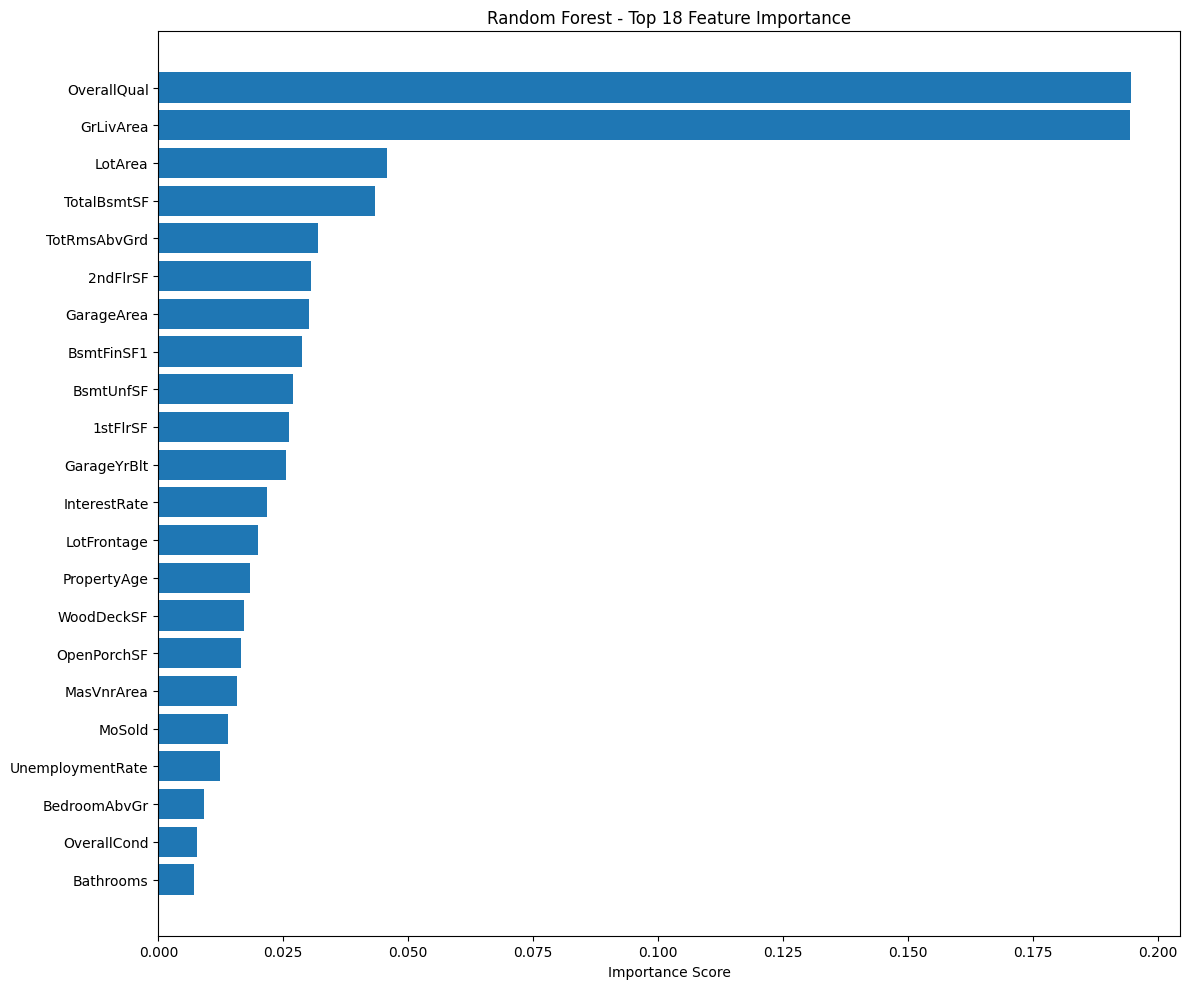


=== Verification Results ===
Hedonic features that are ALSO in Top Random Forest features:


,Hypothesis,Hedonic_Feature,Hedonic_P_Value,In_Top_RF
0,H1b,BedroomAbvGr,0.0056,Yes
1,H1c,Bathrooms,0.0244,Yes
2,H1d,PropertyAge,2.51e-10,Yes
3,H1g,OverallQual,1.68e-06,Yes
4,H1h,LotArea,3.38e-06,Yes
5,H1i,TotRmsAbvGrd,0.0169,Yes
6,H1o,GarageYrBlt,0.0002,Yes
7,H1u,ScreenPorch,0.0113,No



Detailed verification table exported to: output\detailed_verification_table.png


In [25]:
# Prepare data for Random Forest
X = df_engineered.drop(columns=['SalePrice', 'log_SalePrice'], errors='ignore')

# Convert categorical variables to dummy variables for Random Forest
X_encoded = pd.get_dummies(X, drop_first=True)

# Target variable (using original SalePrice for regression)
y = df_engineered['SalePrice']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Create and train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Get feature importance
feature_importance = rf_model.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Get top features using Embedded RF
top_rf_features = feature_importance_df.head(22)
print("\nTop Important Features from Random Forest:")
print(top_rf_features.to_string(index=False))

# Visualize the top features using Embedded RF by graph
plt.figure(figsize=(12, 10))
plt.barh(range(len(top_rf_features)), top_rf_features['importance'][::-1])
plt.yticks(range(len(top_rf_features)), top_rf_features['feature'][::-1])
plt.xlabel('Importance Score')
plt.title('Random Forest - Top 18 Feature Importance')
plt.tight_layout()

# Save the graph as PNG file
rf_importance_plot_path = Path("output") / "random_forest_feature_importance.png"
plt.savefig(rf_importance_plot_path, dpi=300, bbox_inches='tight')
print(f"Random Forest feature importance plot saved to: {rf_importance_plot_path}")

# Display the graph
plt.show()

# Verify Hedonic Feature Selection by comparing with top RF features

# Extract significant features from Hedonic Model (|p-value| < 0.05)
hedonic_significant = []
for h in hypo_specs:
    variable = h['var']
    if h.get('vtype') != 'fe' and variable in ols.params:
        pval = ols.pvalues[variable]
        if -0.05 < pval < 0.05:
            hedonic_significant.append({
                'variable': variable,
                'feature_name': h['feature'],
                'hypothesis': h['H'],
                'coefficient': ols.params[variable],
                'p_value': pval
            })
    elif h.get('vtype') == 'fe':
        # For categorical variables, check if the Wald test was significant
        cat_var = h['feature'].split(' (FE)')[0]
        cat_row = next((row for row in categorical_results 
                       if row['Categorical Variable'] == cat_var), None)
        if cat_row and float(cat_row['P-value']) < 0.05:
            hedonic_significant.append({
                'variable': variable,
                'feature_name': h['feature'],
                'hypothesis': h['H'],
                'coefficient': 'FE (Joint Test)',
                'p_value': float(cat_row['P-value'])
            })

# Create a mapping function to match feature names between methods
def match_feature_names(hedonic_feature_name, rf_features_list):
    """
    Match hedonic feature names with RF feature names by removing (FE) postfix
    and handling categorical dummy variables
    """
    # Remove (FE) postfix from hedonic feature names
    base_name = hedonic_feature_name.replace(' (FE)', '')
    
    # Check for direct matches first
    if base_name in rf_features_list:
        return base_name
    
    # For categorical features, check if any RF feature contains the base name
    # This handles dummy variables like 'Neighborhood_Blmngtn', 'Neighborhood_Blueste', etc.
    matching_features = [rf_feat for rf_feat in rf_features_list if base_name in rf_feat]
    
    if matching_features:
        # Return the highest importance matching feature, or just the first one
        return matching_features[0]
    
    return None

# Check which Hedonic features are in top RF features
print(f"\n=== Verification Results ===")
print("Hedonic features that are ALSO in Top Random Forest features:")

verification_results = []
rf_feature_list = top_rf_features['feature'].tolist()

for hedonic_feat in hedonic_significant:
    # Get the base feature name without (FE) postfix
    hedonic_base_name = hedonic_feat['feature_name'].replace(' (FE)', '')
    
    # Find matching RF feature
    matched_rf_feature = match_feature_names(hedonic_feat['feature_name'], rf_feature_list)
    in_top = matched_rf_feature is not None
    
    # Get RF importance score if matched
    rf_importance = "N/A"
    if matched_rf_feature:
        rf_importance = top_rf_features[top_rf_features['feature'] == matched_rf_feature]['importance'].values[0]
        rf_importance = f"{rf_importance:.4f}"
    
    verification_results.append({
        'Hypothesis': hedonic_feat['hypothesis'],
        'Hedonic_Feature': hedonic_feat['feature_name'],
        'Hedonic_P_Value': format_number(hedonic_feat['p_value']),
        'In_Top_RF': 'Yes' if in_top else 'No'
    })

# Create and display verification table
verification_df = pd.DataFrame(verification_results)
# print(f"\nDetailed Verification Table:")
# print(verification_df.to_string(index=False))

# Export the Detailed Verification Table as PNG file
styled_verification = (
    verification_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])
)

# Display in notebook
display(styled_verification)

# Export as PNG
verification_png_path = Path("output") / "detailed_verification_table.png"
dfi.export(styled_verification, verification_png_path, table_conversion='chrome')
print(f"\nDetailed verification table exported to: {verification_png_path}")

# # Calculate agreement statistics
# total_hedonic_features = len(verification_results)
# agreed_features = len([r for r in verification_results if r['In_Top_RF'] == 'Yes'])
# agreement_rate = (agreed_features / total_hedonic_features) * 100

# print(f"\n=== Agreement Statistics ===")
# print(f"Total Hedonic Significant Features: {total_hedonic_features}")
# print(f"Features also in Top RF: {agreed_features}")
# print(f"Agreement Rate: {agreement_rate:.1f}%")

### 9 Create and save df with selected featuers

In [26]:
# Creat and save df_selected from hedonic model

# Variables selected by hedonic model (significant ones)
hedonic_vars = [h['variable'] for h in hedonic_significant]

# Map from formula / log names back to original data columns
name_map = {
    'log_ScreenPorch': 'ScreenPorch',   
    'log_MedianIncome': 'MedianIncome'  
}
hedonic_base_cols = [name_map.get(v, v) for v in hedonic_vars]

# Keep macro factors 
# macro_cols = ['MedianIncome', 'CrimeRate', 'InterestRate', 'UnemploymentRate']

# Categorical FE variables
# categorical_vars = ['LotShape', 'BsmtExposure', 'GarageYrBlt',
#                     'BldgType', 'YrSold', 'MoSold', 'QrtSold']

categorical_vars = ['YrSold', 'MoSold', 'QrtSold']

# Target variable
target_col = 'SalePrice'

# Combine 
cols_selected = (
    [target_col] +
    hedonic_base_cols +
    # macro_cols +
    categorical_vars
)
cols_selected = list(dict.fromkeys(
    [c for c in cols_selected if c in df_engineered.columns]
))

# Create df_selected
df_selected = df_engineered[cols_selected].copy()
print("df_selected shape:", df_selected.shape)
print("df_selected columns:", df_selected.columns.tolist())

# Save to CSV
output_dir = Path("output/preprocess_csv")
output_dir.mkdir(parents=True, exist_ok=True)
df_selected_path = output_dir / "df_selected.csv"
df_selected.to_csv(df_selected_path, index=False)
print(f"df_selected saved to: {df_selected_path}")


df_selected shape: (2919, 11)
df_selected columns: ['SalePrice', 'BedroomAbvGr', 'Bathrooms', 'PropertyAge', 'OverallQual', 'LotArea', 'TotRmsAbvGrd', 'ScreenPorch', 'YrSold', 'MoSold', 'QrtSold']
df_selected saved to: output\preprocess_csv\df_selected.csv
